# Roadmap

*← Back to the globe*

Do you want to know how many people die in a second worldwide? Let's ask the machine.

```
Q: How many people die a second?
A: Roughly 2 people die every second globally
```

The problem is that that's not true. Or not completely true. The truth behind this statement is that for the last couple years 60 million to 63 million people died every year, worldwide. A year has 1'314'000 second (60 seconds x 60 minutes x 365 days). If we divide the number of seconds in a year by the number of defuncitions in a year it certainly gives ~2 deaths/second. But that's just on average, on a yearly average.

[blinking dot every 500ms]

In reality there's a big chance that during any given second nobody dies, because deaths don't happen on a steady rhythm. In fact, if deaths where randomly distributed accross the year there would only be a one in three chance that two people died any given second, the same chances of only one person dying on a given second.

[chart showing how many days in a year what number of people would die]
```
lambda = 2

for k = 0 to 7:
    probability[k] = exp(-lambda) * lambda^k / factorial(k)
    days[k] = 365 * probability[k]

probability[8+] = 1 - sum(probability[0..7])
days[8+] = 365 * probability[8+]
```

So, how many people die on a given second? Our new (better) answer is: if people die randomly around the year, probably somewhere *between 0 and 4* (we can say this with a ~95% certainty). This dot behaves in this way.

[blinking dot randomly blinking]

**● Implemented**  ·  **○ Planned**

---

*This notebook recreates the [`/roadmap`](../app/roadmap/page.tsx) page — same text, same maps — as static matplotlib figures over the project's committed `data/*.json`. Maps that animate on the web (steps 1–3) are shown here as single representative snapshots. Drawing convention follows `notebooks/seasonality.ipynb`: hand-decoded world-atlas TopoJSON, flat lon/lat (equirectangular).*

In [2]:
"""Setup: load committed data and define shared helpers (ported from
app/roadmap/chartHelpers.ts and notebooks/seasonality.ipynb)."""

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.collections import PolyCollection
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import Rectangle


def find_root() -> Path:
    p = Path.cwd()
    for cand in [p, *p.parents]:
        if (cand / "package.json").exists():
            return cand
    raise FileNotFoundError("package.json not found in any parent")


ROOT = find_root()
DATA = ROOT / "data"


def load(name: str):
    return json.load(open(DATA / name))


rate_grid = load("rate-grid.json")
density_grid = load("density-grid.json")
seasonality = load("seasonality.json")
try:
    unified = load("seasonality-unified.json")
except FileNotFoundError:
    unified = None
active = unified or seasonality  # page uses `unified || seasonality`
admin1 = load("admin1-10m.json")
nuts2 = load("nuts2-20m.json")
subnational = load("subnational-cdr.json")

# --- dark theme roughly matching the web page -------------------------------------
plt.rcParams.update({
    "figure.facecolor": "#0a0a0f", "axes.facecolor": "#0a0a0f",
    "savefig.facecolor": "#0a0a0f", "text.color": "#e8e8ea",
    "axes.labelcolor": "#cfcfd4", "xtick.color": "#9a9aa2", "ytick.color": "#9a9aa2",
    "axes.edgecolor": "#3a3a44", "font.size": 11, "figure.dpi": 110,
})

# world-atlas country ids are M49 numeric strings; map to ISO3 (Kosovo has no ISO3).
M49_TO_ISO3 = {
    "004": "AFG", "008": "ALB", "010": "ATA", "012": "DZA", "024": "AGO", "031": "AZE",
    "032": "ARG", "036": "AUS", "040": "AUT", "044": "BHS", "050": "BGD", "051": "ARM",
    "056": "BEL", "064": "BTN", "068": "BOL", "070": "BIH", "072": "BWA", "076": "BRA",
    "084": "BLZ", "090": "SLB", "096": "BRN", "100": "BGR", "104": "MMR", "108": "BDI",
    "112": "BLR", "116": "KHM", "120": "CMR", "124": "CAN", "140": "CAF", "144": "LKA",
    "148": "TCD", "152": "CHL", "156": "CHN", "158": "TWN", "170": "COL", "178": "COG",
    "180": "COD", "188": "CRI", "191": "HRV", "192": "CUB", "196": "CYP", "203": "CZE",
    "204": "BEN", "208": "DNK", "214": "DOM", "218": "ECU", "222": "SLV", "226": "GNQ",
    "231": "ETH", "232": "ERI", "233": "EST", "238": "FLK", "242": "FJI", "246": "FIN",
    "250": "FRA", "260": "ATF", "262": "DJI", "266": "GAB", "268": "GEO", "270": "GMB",
    "275": "PSE", "276": "DEU", "288": "GHA", "300": "GRC", "304": "GRL", "320": "GTM",
    "324": "GIN", "328": "GUY", "332": "HTI", "340": "HND", "348": "HUN", "352": "ISL",
    "356": "IND", "360": "IDN", "364": "IRN", "368": "IRQ", "372": "IRL", "376": "ISR",
    "380": "ITA", "384": "CIV", "388": "JAM", "392": "JPN", "398": "KAZ", "400": "JOR",
    "404": "KEN", "408": "PRK", "410": "KOR", "414": "KWT", "417": "KGZ", "418": "LAO",
    "422": "LBN", "426": "LSO", "428": "LVA", "430": "LBR", "434": "LBY", "440": "LTU",
    "442": "LUX", "450": "MDG", "454": "MWI", "458": "MYS", "466": "MLI", "478": "MRT",
    "484": "MEX", "496": "MNG", "498": "MDA", "499": "MNE", "504": "MAR", "508": "MOZ",
    "512": "OMN", "516": "NAM", "524": "NPL", "528": "NLD", "540": "NCL", "548": "VUT",
    "554": "NZL", "558": "NIC", "562": "NER", "566": "NGA", "578": "NOR", "586": "PAK",
    "591": "PAN", "598": "PNG", "600": "PRY", "604": "PER", "608": "PHL", "616": "POL",
    "620": "PRT", "624": "GNB", "626": "TLS", "630": "PRI", "634": "QAT", "642": "ROU",
    "643": "RUS", "646": "RWA", "682": "SAU", "686": "SEN", "688": "SRB", "694": "SLE",
    "703": "SVK", "704": "VNM", "705": "SVN", "706": "SOM", "710": "ZAF", "716": "ZWE",
    "724": "ESP", "728": "SSD", "729": "SDN", "732": "ESH", "740": "SUR", "748": "SWZ",
    "752": "SWE", "756": "CHE", "760": "SYR", "762": "TJK", "764": "THA", "768": "TGO",
    "780": "TTO", "784": "ARE", "788": "TUN", "792": "TUR", "795": "TKM", "800": "UGA",
    "804": "UKR", "807": "MKD", "818": "EGY", "826": "GBR", "834": "TZA", "840": "USA",
    "854": "BFA", "858": "URY", "860": "UZB", "862": "VEN", "887": "YEM", "894": "ZMB",
}


def decode_topojson(topo: dict, object_name: str) -> list[dict]:
    """Decode a TopoJSON object to a list of {id, props, rings} in lon/lat.
    Rings are outer-ring only, antimeridian-split — enough for choropleths."""
    sx, sy = topo["transform"]["scale"]
    tx, ty = topo["transform"]["translate"]
    arcs = []
    for arc in topo["arcs"]:
        x = y = 0
        pts = []
        for dx, dy in arc:
            x += dx
            y += dy
            pts.append((x * sx + tx, y * sy + ty))
        arcs.append(pts)

    def ring(arc_ids):
        coords = []
        for idx in arc_ids:
            seg = arcs[idx] if idx >= 0 else arcs[~idx][::-1]
            coords.extend(seg if not coords else seg[1:])
        return coords

    def split(r):
        parts, cur = [], [r[0]]
        for p in r[1:]:
            if abs(p[0] - cur[-1][0]) > 180:  # antimeridian jump -> new sub-path
                parts.append(cur)
                cur = [p]
            else:
                cur.append(p)
        parts.append(cur)
        return [pp for pp in parts if len(pp) >= 3]

    out = []
    for g in topo["objects"][object_name]["geometries"]:
        if g["type"] == "Polygon":
            polys = [g["arcs"]]
        elif g["type"] == "MultiPolygon":
            polys = g["arcs"]
        else:
            polys = []
        rings = [rr for poly in polys for rr in split(ring(poly[0]))]
        out.append({"id": g.get("id"), "props": g.get("properties", {}), "rings": rings})
    return out


countries = decode_topojson(load("countries-110m.json")
                            if (DATA / "countries-110m.json").exists()
                            else json.load(open(ROOT / "node_modules/world-atlas/countries-110m.json")),
                            "countries")
rings_by_m49 = {c["id"]: c["rings"] for c in countries}
name_by_m49 = {c["id"]: c["props"].get("name") for c in countries}


def polygon_centroid(rings: list) -> tuple[float, float] | None:
    """Area-weighted centroid of the largest ring (shoelace)."""
    if not rings:
        return None
    ring = max(rings, key=len)
    a = cx = cy = 0.0
    for (x0, y0), (x1, y1) in zip(ring, ring[1:] + ring[:1], strict=False):
        cross = x0 * y1 - x1 * y0
        a += cross
        cx += (x0 + x1) * cross
        cy += (y0 + y1) * cross
    if abs(a) < 1e-9:
        xs, ys = zip(*ring, strict=False)
        return sum(xs) / len(xs), sum(ys) / len(ys)
    a *= 0.5
    return cx / (6 * a), cy / (6 * a)


centroid_by_m49 = {m49: polygon_centroid(r) for m49, r in rings_by_m49.items()}

# deaths/yr per M49 = sum of rate-grid cell weights (cells: [lon, lat, m49, w]).
deaths_by_m49: dict[int, float] = {}
for _lon, _lat, m49, w in rate_grid["cells"]:
    deaths_by_m49[m49] = deaths_by_m49.get(m49, 0.0) + w

# --- chartHelpers.ts ports --------------------------------------------------------
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]


def strength(values) -> float:
    return max(abs(v - 1) for v in values)


def rotate_six(values):
    return list(values[6:]) + list(values[:6])


def fallback_amplitude_for_lat(lat: float, seas: dict) -> float:
    fb = seas.get("fallback", {})
    abs_lat = abs(lat)
    coef, clamp = fb.get("amplitudeCoef"), fb.get("ampClamp")
    if coef and clamp:
        a, b, c = coef
        lo, hi = clamp
        pct = max(lo, min(hi, a * abs_lat * abs_lat + b * abs_lat + c))
        return pct / 100
    # latitude-plateau branch (data/seasonality.json)
    t_max, plateau = fb.get("tropicMaxAbsLat", 0), fb.get("plateauAbsLat", 0)
    t = max(0.0, min(1.0, (abs_lat - t_max) / (plateau - t_max))) if plateau != t_max else 0.0
    return t * strength(fb["north"])


COUNTRY_CURVE_PICKS = [
    (250, "France", "#ff6b6b"), (703, "Slovakia", "#ffb26b"), (840, "USA", "#f4d35e"),
    (752, "Sweden", "#4ade80"), (392, "Japan", "#2dd4bf"), (191, "Croatia", "#6ba8ff"),
    (56, "Belgium", "#818cf8"), (826, "United Kingdom", "#c084fc"),
    (756, "Switzerland", "#f472b6"), (528, "Netherlands", "#facc15"),
]

CLIMATE_ZONES = [
    ("Tropical", 0, 23.5, "#5b3a42"), ("Subtropical", 23.5, 35, "#7a3f3f"),
    ("Middle latitude", 35, 66.5, "#8a4a5a"), ("Polar", 66.5, 90, "#2f4a63"),
]

RNG = np.random.default_rng(7)  # seeded so snapshots are reproducible


def random_point_on_sphere():
    lon = RNG.random() * 360 - 180
    lat = math.degrees(math.asin(2 * RNG.random() - 1))
    return lon, lat


def style_world(ax, title):
    ax.set_xlim(-180, 180)
    ax.set_ylim(-58, 84)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=13, color="#e8e8ea")


# Sequential dark->red colormap shared by the density + amplitude maps (matches the
# web's interpolateRgb("#1c2331","#ff5252") / ("#233142","#ff6b6b")).
DENSITY_CMAP = LinearSegmentedColormap.from_list("wpdl_density", ["#1c2331", "#ff5252"])
AMP_CMAP = LinearSegmentedColormap.from_list("wpdl_amp", ["#233142", "#ff6b6b"])

print(f"root={ROOT.name}  countries={len(rings_by_m49)}  "
      f"deaths countries={len(deaths_by_m49)}  unified={'yes' if unified else 'no'}  "
      f"subnational regions={len(subnational['regions'])}")


root=watch-people-die-live  countries=175  deaths countries=226  unified=yes  subnational regions=981


## Mortality

### ● 1 · Global Death Rate

Globally, nearly two people die every second — one death roughly every half-second.

> Source: World Bank Open Data — crude death rate and population (indicators SP.DYN.CDRT.IN and SP.POP.TOTL).

The first layer only matches the global average: about two deaths every second. Timing
is random, not metronomic, so the gap between dots is drawn from an exponential
distribution. Location is also fully random across the Earth's surface, so this
baseline deliberately ignores countries, population density, seasons, and time zones.

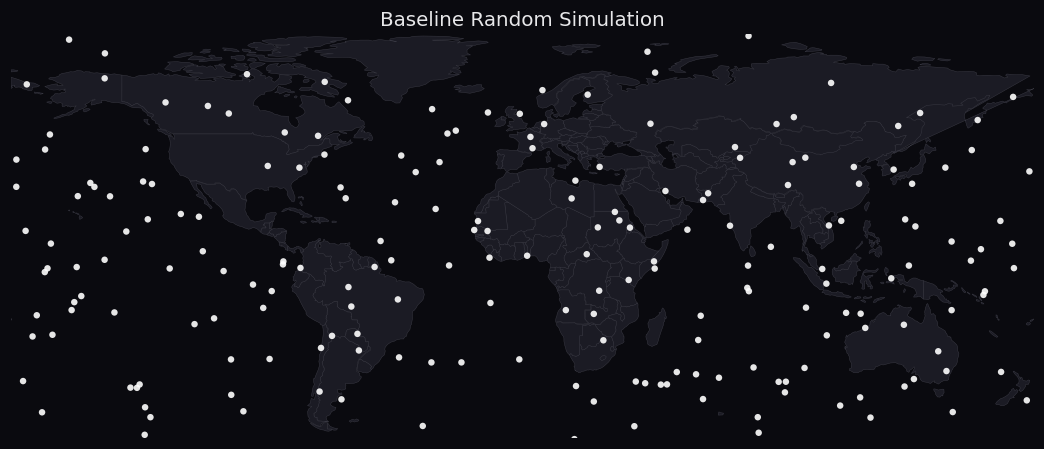

White dots appear at exponentially random intervals, averaging nearly two events
every second (~0.5s between deaths), and at uniformly random points on the Earth's
surface. This first layer has no country, density, or seasonality weighting.


In [2]:
# Baseline Random Simulation — static snapshot of the animated dot stream.
fig, ax = plt.subplots(figsize=(12, 5))
for _m49, rings in rings_by_m49.items():
    if rings:
        ax.add_collection(PolyCollection(rings, facecolor="#1b1b24",
                                         edgecolor="#3a3a44", linewidth=0.3))
pts = np.array([random_point_on_sphere() for _ in range(220)])
ax.scatter(pts[:, 0], pts[:, 1], s=18, c="white", edgecolors="none", alpha=0.9, zorder=3)
style_world(ax, "Baseline Random Simulation")
plt.show()
print("White dots appear at exponentially random intervals, averaging nearly two events\n"
      "every second (~0.5s between deaths), and at uniformly random points on the Earth's\n"
      "surface. This first layer has no country, density, or seasonality weighting.")


### ● 2 · Death Rate By Country

Country-level mortality is measured consistently across every country in the world.

> Source: World Bank crude death rate by country (derived from UN World Population Prospects).

In 2000, Mexico and Lithuania both had life expectancy around 72 years, but Mexico's
crude death rate was about 4 per 1,000, while Lithuania's was about 11 per 1,000. Same
life expectancy, almost 3× crude death rate difference.
([Source](https://www.sciencedirect.com/topics/mathematics/crude-death-rate).)

Each country now fires deaths at its own real annual rate instead of the flat global
average — populous countries pulse far more often than sparse ones. But within a
country, every death still lands on exactly the same point: its geographic center. Step
3 fixes that by spreading deaths out realistically inside each border.

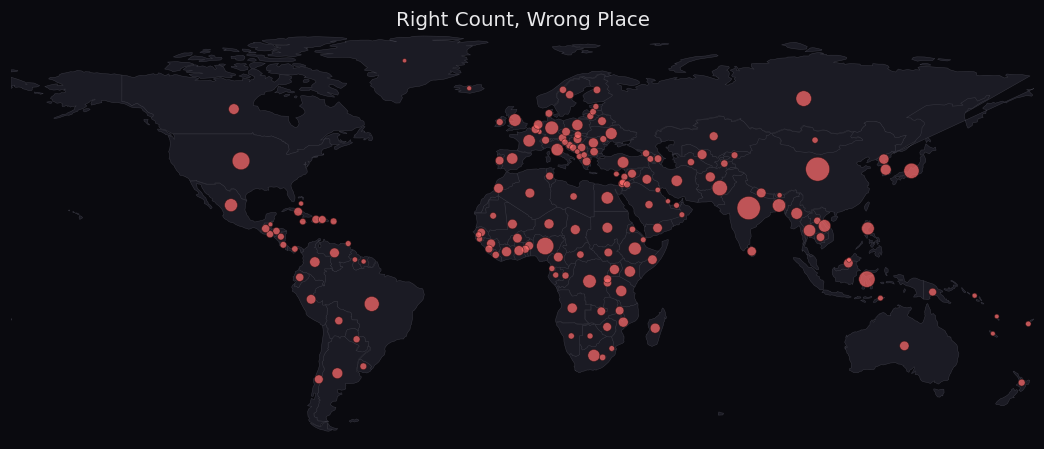

Each country now fires deaths at its own real rate — populous countries pulse faster —
but every death still lands on the same single point: that country's geographic center.
Step 3 spreads them out realistically inside each border.


In [3]:
# Right Count, Wrong Place — every country's deaths pile on its geographic centroid,
# marker area proportional to real deaths/year.
fig, ax = plt.subplots(figsize=(12, 5))
for _m49, rings in rings_by_m49.items():
    if rings:
        ax.add_collection(PolyCollection(rings, facecolor="#1b1b24",
                                         edgecolor="#3a3a44", linewidth=0.3))
xs, ys, sizes = [], [], []
for m49, c in centroid_by_m49.items():
    d = deaths_by_m49.get(m49)  # rate-grid m49 ids are ints; topo ids are strings
    if d is None and m49 is not None:
        d = deaths_by_m49.get(int(m49)) if str(m49).isdigit() else None
    if c and d:
        xs.append(c[0]); ys.append(c[1]); sizes.append(d)
sizes = np.array(sizes)
areas = 6 + 240 * np.sqrt(sizes / sizes.max())  # area ~ sqrt(deaths) so radius ~ deaths^0.25
ax.scatter(xs, ys, s=areas, c="#ff6b6b", alpha=0.72, edgecolors="#2a0f10",
           linewidths=0.4, zorder=3)
style_world(ax, "Right Count, Wrong Place")
plt.show()
print("Each country now fires deaths at its own real rate — populous countries pulse faster —\n"
      "but every death still lands on the same single point: that country's geographic center.\n"
      "Step 3 spreads them out realistically inside each border.")


### ● 3 · Population Density

Deaths correlate strongly with population density — more people die in Paris than in Antarctica.

> Source: Gridded Population of the World v4 (GPWv4, CIESIN), aggregated to a 0.5° density grid.

Step 2 gave each country its correct death count; density decides where inside that
country those deaths actually land. Each 0.5° grid cell carries a population count, and
a country's deaths are split across its cells in proportion to how many people live in
each one — so a death is far more likely to land in a city than in open countryside.

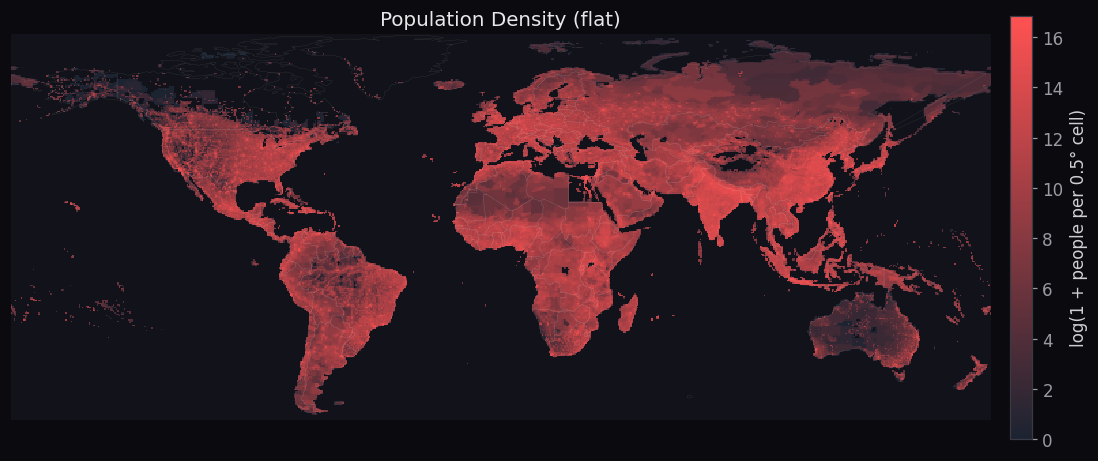

GPWv4 population counts on the 0.5° grid, equal-earth projection. Brighter cells hold
more people. Dots now land on a grid cell chosen in proportion to that cell's population,
instead of a country's single geographic center.


In [4]:
# Population Density (flat) — the 0.5deg GPWv4 grid rasterised to log1p(pop).
cs = density_grid["cellsize"]
ncol, nrow = int(round(360 / cs)), int(round(180 / cs))
grid = np.full((nrow, ncol), np.nan)
for lon, lat, pop, _m49 in density_grid["cells"]:
    col = int(round((lon + 180) / cs))
    row = int(round((lat + 90) / cs))
    if 0 <= row < nrow and 0 <= col < ncol:
        grid[row, col] = math.log1p(pop)

cmap = DENSITY_CMAP.copy()
cmap.set_bad("#12121a")
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(np.ma.masked_invalid(grid), origin="lower", extent=[-180, 180, -90, 90],
               cmap=cmap, interpolation="nearest")
for _m49, rings in rings_by_m49.items():
    if rings:
        ax.add_collection(PolyCollection(rings, facecolor="none",
                                         edgecolor="#ffffff22", linewidth=0.25))
style_world(ax, "Population Density (flat)")
cbar = fig.colorbar(im, ax=ax, fraction=0.023, pad=0.02)
cbar.set_label("log(1 + people per 0.5° cell)", color="#cfcfd4")
plt.show()
print("GPWv4 population counts on the 0.5° grid, equal-earth projection. Brighter cells hold\n"
      "more people. Dots now land on a grid cell chosen in proportion to that cell's population,\n"
      "instead of a country's single geographic center.")


Applying the raster grid to the vector country map isn't perfectly clean, though:
country borders come from smooth vector polygons (topojson), while the population grid
is a blocky 0.5° raster (~55 km per cell). Near a border, a single raster cell can
straddle two countries — the close-up below shows exactly that overlap.

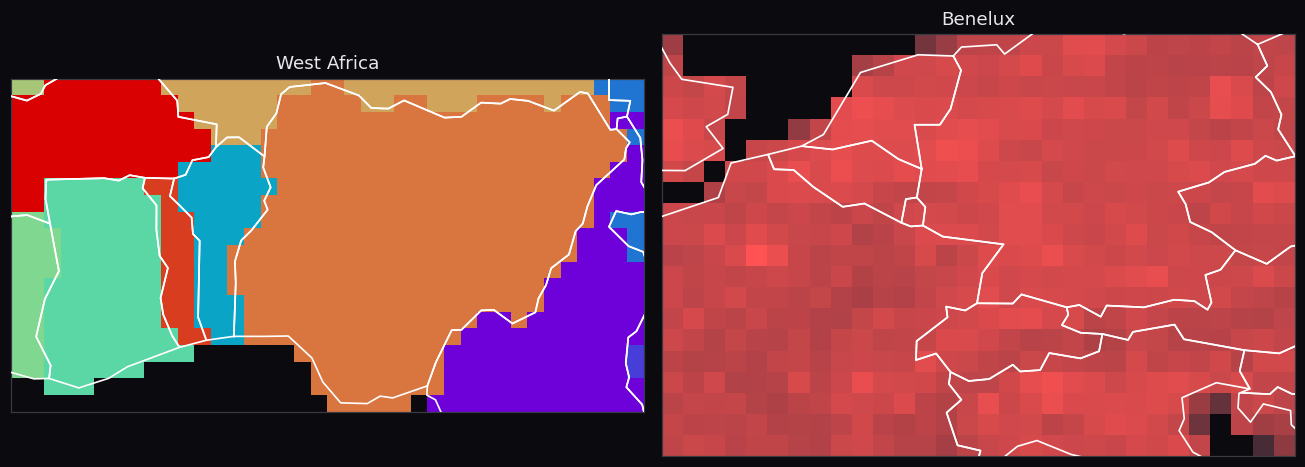

In [5]:
# Border vs raster close-ups: each 0.5deg cell drawn as a square, smooth vector borders
# on top. West Africa colored by raster-owning country; Benelux colored by density.
def closeup(ax, bbox, title, color_by):
    (lon0, lat0), (lon1, lat1) = bbox
    in_view = [(lon, lat, pop, m49) for lon, lat, pop, m49 in density_grid["cells"]
               if lon0 - cs <= lon <= lon1 and lat0 - cs <= lat <= lat1]
    if color_by == "country":
        ids = sorted({m49 for *_, m49 in in_view})
        rainbow = plt.get_cmap("rainbow")
        col_of = {m: rainbow(i / max(1, len(ids) - 1)) for i, m in enumerate(ids)}
        for lon, lat, _pop, m49 in in_view:
            ax.add_patch(Rectangle((lon, lat), cs, cs, facecolor=col_of[m49],
                                   edgecolor="none", alpha=0.85))
    else:
        vmax = max((math.log1p(p) for _, _, p, _ in in_view), default=1) or 1
        for lon, lat, pop, _m49 in in_view:
            ax.add_patch(Rectangle((lon, lat), cs, cs,
                                   facecolor=DENSITY_CMAP(math.log1p(pop) / vmax),
                                   edgecolor="none"))
    for rings in rings_by_m49.values():
        for r in rings:
            xs, ys = zip(*r, strict=False)
            ax.plot(xs, ys, color="white", linewidth=1.1, zorder=3)
    ax.set_xlim(lon0, lon1)
    ax.set_ylim(lat0, lat1)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=12, color="#e8e8ea")


fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
closeup(axes[0], [[-4, 4], [15, 14]], "West Africa", "country")
closeup(axes[1], [[0, 44], [15, 54]], "Benelux", "density")
plt.tight_layout()
plt.show()


### ● 4 · Death Rate By Time Of Year

Mortality varies by season — winter respiratory and cardiovascular excess, and summer heat deaths.

> Source: UN Demographic Yearbook monthly deaths, with a latitude-scaled fallback for countries without monthly reports.

The seasonal layer keeps each country's annual death total unchanged. It only
redistributes timing across months: a factor above 1 means deaths fire faster than the
annual average, and a factor below 1 means they fire slower. Today that's a direct,
measured curve for 27 countries with stable UN monthly data — everyone else uses a
latitude-scaled fallback instead, since winter deviation strengthens outside the tropics
and (in the current model) plateaus around mid-latitudes.

But what should the other ~170 countries without direct monthly data do? Two richer
sources are under evaluation to shrink that gap: the [Human Mortality Database's
Short-Term Mortality Fluctuations](https://www.mortality.org/Data/STMF) series (weekly
deaths, 38 countries including the US, France, and Australia) and the [World Mortality
Dataset](https://github.com/akarlinsky/world_mortality) (weekly or monthly, 100+
countries/territories). Folding both in — see `notebooks/seasonality.ipynb` — would
raise direct-curve coverage from 27 to around 90 countries. For whoever is left, the
same analysis found the fallback's flat-then-plateau latitude ramp underfits the real
pattern: amplitude actually peaks near 40° and tapers off closer to the poles, rather
than staying flat past 40° as the current fallback assumes — so the fallback itself is
also due for a fix.

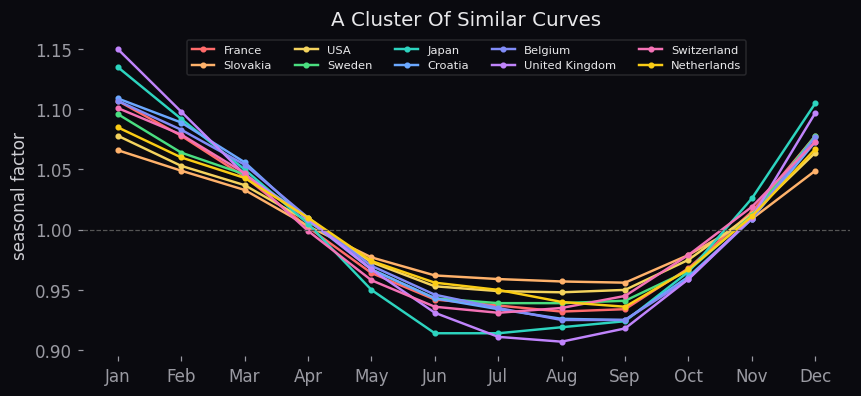

Ten countries whose measured curves are mutually similar in shape (average pairwise
correlation r=0.994) despite spanning very different latitudes and death tolls — Japan
and the USA track the same winter/summer timing as France, the UK, and the Benelux
countries. 6 of these 10 curves come from the notebook's unified sources, not the
27-country data/seasonality.json shipped today.


In [6]:
# A Cluster Of Similar Curves — 10 countries' monthly seasonal factors.
fig, ax = plt.subplots(figsize=(9, 3.8))
x = range(1, 13)
for m49, name, color in COUNTRY_CURVE_PICKS:
    curve = active["countries"].get(str(m49))
    if curve:
        ax.plot(x, curve, marker="o", markersize=3, linewidth=1.6, color=color, label=name)
ax.axhline(1, color="#555", linewidth=0.8, linestyle="--")
ax.set_xticks(list(x))
ax.set_xticklabels(MONTHS)
ax.set_ylabel("seasonal factor")
ax.set_title("A Cluster Of Similar Curves", fontsize=13, color="#e8e8ea")
ax.legend(ncol=5, fontsize=7.5, loc="upper center", framealpha=0.15)
for s in ax.spines.values():
    s.set_visible(False)
plt.show()
print("Ten countries whose measured curves are mutually similar in shape (average pairwise\n"
      "correlation r=0.994) despite spanning very different latitudes and death tolls — Japan\n"
      "and the USA track the same winter/summer timing as France, the UK, and the Benelux\n"
      "countries. 6 of these 10 curves come from the notebook's unified sources, not the\n"
      "27-country data/seasonality.json shipped today.")


**Seasonal Mortality Amplitude (Unified)** — Every country with a measured curve from
the notebook's unified sources, colored by its own seasonal amplitude — 87 countries
instead of the 27 in `data/seasonality.json`. Grey still means no direct data.

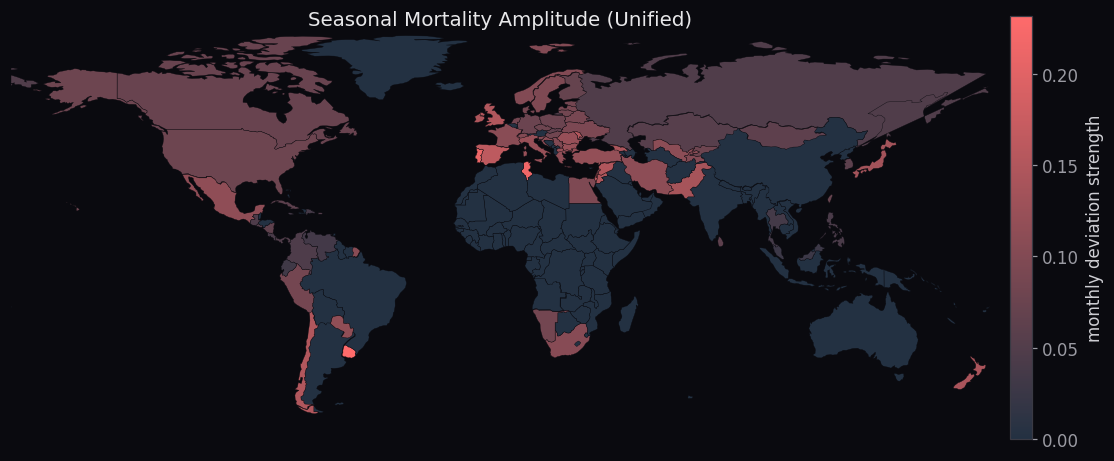

Every country with a measured curve from the notebook's unified sources, colored by its
own seasonal amplitude — 87 countries instead of the 27 in data/seasonality.json.
Grey still means no direct data.


In [7]:
# Amplitude choropleth helper (reused for both amplitude maps below).
def observed_amplitude_by_m49(seas):
    return {m49: strength(curve) for m49, curve in seas["countries"].items()}


AMP_VMAX = max(observed_amplitude_by_m49(active).values())


def draw_amplitude(value_by_m49, title, caption, edges=True):
    norm = Normalize(0, AMP_VMAX)
    fig, ax = plt.subplots(figsize=(12, 5))
    for m49, rings in rings_by_m49.items():
        if not rings:
            continue
        v = value_by_m49.get(m49)
        color = AMP_CMAP(norm(v)) if v is not None else "#233142"
        ax.add_collection(PolyCollection(
            rings, facecolor=color,
            edgecolor="#0a0a0f" if edges else "none",
            linewidth=0.25 if edges else 0))
    style_world(ax, title)
    cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=AMP_CMAP), ax=ax,
                        fraction=0.023, pad=0.02)
    cbar.set_label("monthly deviation strength", color="#cfcfd4")
    plt.show()
    print(caption)


draw_amplitude(
    observed_amplitude_by_m49(unified),
    "Seasonal Mortality Amplitude (Unified)",
    "Every country with a measured curve from the notebook's unified sources, colored by its\n"
    "own seasonal amplitude — 87 countries instead of the 27 in data/seasonality.json.\n"
    "Grey still means no direct data.")


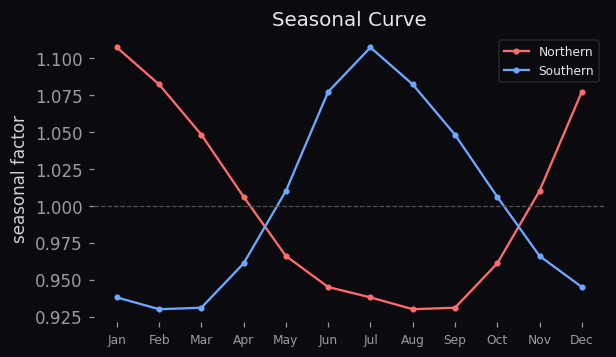

Canonical curve averaged across the unified dataset's best-covered countries
(phase-aligned across hemispheres first), shown north and south. This is the shape the
continuous fallback below rescales to match each country's predicted amplitude.


In [8]:
# Seasonal Curve — canonical north shape and its 6-month-shifted southern mirror.
north = active["fallback"]["north"]
south = rotate_six(north)
fig, ax = plt.subplots(figsize=(6, 3.4))
x = range(1, 13)
ax.plot(x, north, marker="o", markersize=3, color="#ff6b6b", label="Northern")
ax.plot(x, south, marker="o", markersize=3, color="#6ba8ff", label="Southern")
ax.axhline(1, color="#555", linewidth=0.8, linestyle="--")
ax.set_xticks(list(x)); ax.set_xticklabels(MONTHS, fontsize=8)
ax.set_ylabel("seasonal factor")
ax.set_title("Seasonal Curve", fontsize=13, color="#e8e8ea")
ax.legend(fontsize=8, framealpha=0.15)
for s in ax.spines.values():
    s.set_visible(False)
plt.show()
print("Canonical curve averaged across the unified dataset's best-covered countries\n"
      "(phase-aligned across hemispheres first), shown north and south. This is the shape the\n"
      "continuous fallback below rescales to match each country's predicted amplitude.")


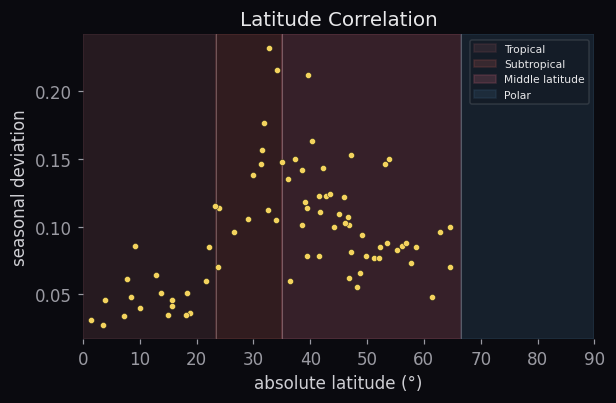

87 countries from the unified dataset, plotted by latitude and climate zone.
Amplitude peaks in the middle latitudes rather than rising all the way to the poles,
unlike the old fallback's flat plateau past 40°. (76 fall inside the 110m basemap.)


In [9]:
# Latitude Correlation — amplitude vs absolute latitude, shaded by climate zone.
fig, ax = plt.subplots(figsize=(6, 3.6))
for name, lo, hi, color in CLIMATE_ZONES:
    ax.axvspan(lo, hi, color=color, alpha=0.35, label=name)
for b in (23.5, 35, 66.5):
    ax.axvline(b, color="#ffffff33", linewidth=0.7)
xs, ys = [], []
for m49, curve in active["countries"].items():
    c = centroid_by_m49.get(m49)
    if c:
        xs.append(abs(c[1]))
        ys.append(strength(curve))
ax.scatter(xs, ys, s=16, c="#f4d35e", edgecolors="#1a1a1a", linewidths=0.3, zorder=3)
ax.set_xlim(0, 90)
ax.set_xlabel("absolute latitude (°)")
ax.set_ylabel("seasonal deviation")
ax.set_title("Latitude Correlation", fontsize=13, color="#e8e8ea")
ax.legend(fontsize=7, framealpha=0.15, loc="upper right")
for s in ax.spines.values():
    s.set_visible(False)
plt.show()
print("87 countries from the unified dataset, plotted by latitude and climate zone.\n"
      "Amplitude peaks in the middle latitudes rather than rising all the way to the poles,\n"
      f"unlike the old fallback's flat plateau past 40°. ({len(xs)} fall inside the 110m basemap.)")


**Amplitude By Country** — Every rendered country is colored by seasonal amplitude:
observed curves where available, and the fitted latitude fallback everywhere else.
Borders are removed so the map reads as a continuous amplitude surface.

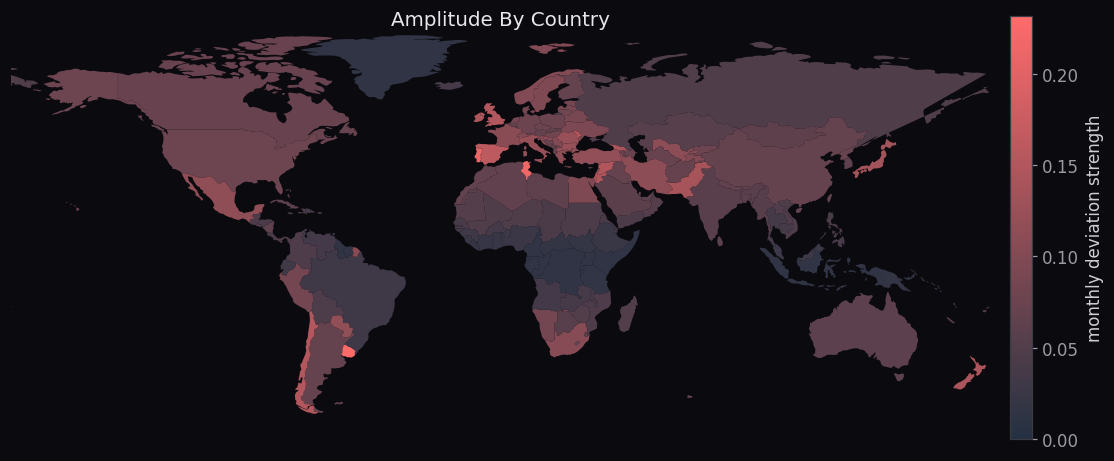

Every rendered country is colored by seasonal amplitude: observed curves where available,
and the fitted latitude fallback everywhere else. Borders are removed so the map reads as
a continuous amplitude surface.

Deviation is measured as the largest monthly percent difference from the annual average.


In [10]:
# Amplitude By Country — observed curves, latitude fallback everywhere else, no borders.
observed = observed_amplitude_by_m49(active)
value_by_m49 = {}
for m49, _rings in rings_by_m49.items():
    if m49 in observed:
        value_by_m49[m49] = observed[m49]
    else:
        c = centroid_by_m49.get(m49)
        if c:
            value_by_m49[m49] = fallback_amplitude_for_lat(c[1], active)

draw_amplitude(
    value_by_m49,
    "Amplitude By Country",
    "Every rendered country is colored by seasonal amplitude: observed curves where available,\n"
    "and the fitted latitude fallback everywhere else. Borders are removed so the map reads as\n"
    "a continuous amplitude surface.",
    edges=False)
print("\nDeviation is measured as the largest monthly percent difference from the annual average.")


**Does temperature actually predict the curve better than latitude?** — A leave-one-country-out
validation (`notebooks/seasonality.ipynb`) tests this directly: for each of 86 countries, hide its
mortality curve, keep its population-weighted temperature curve, and predict from its 5 nearest
temperature-profile donors — never letting the held-out country leak into its own baseline. Charts
below are generated from `data/seasonality-loo-validation.json`, baked by that notebook.

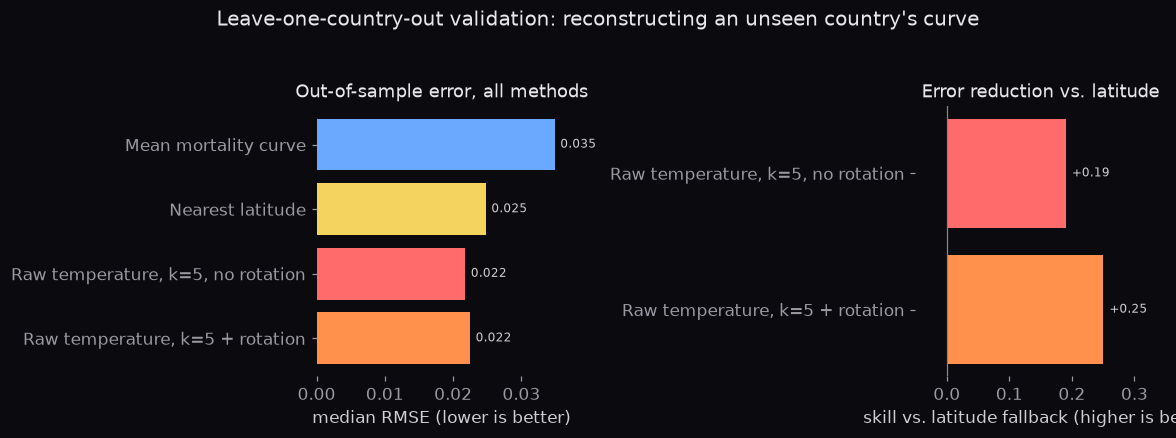

86 countries held out one at a time. Both temperature variants beat
the latitude fallback (positive skill); the plain mean-curve floor is far worse than latitude
(skill vs. latitude = -1.59, off the right-hand scale above).


In [16]:
# Model Comparison — median RMSE (all methods) and skill vs. latitude (temperature methods only;
# the mean-curve baseline's skill vs. latitude is a huge negative outlier that would swamp the
# interesting comparison, so it's called out as a text annotation instead).
loo = load("seasonality-loo-validation.json")
table = loo["comparisonTable"]

methods = [row["Method"] for row in table]
rmse = [row["Median RMSE"] for row in table]
colors = ["#6ba8ff", "#f4d35e", "#ff6b6b", "#ff914d"][: len(methods)]

mean_curve_skill = next(row["Skill vs latitude"] for row in table if row["Method"] == "Mean mortality curve")
temp_rows = [row for row in table if row["Method"] not in ("Mean mortality curve", "Nearest latitude")]
temp_methods = [row["Method"] for row in temp_rows]
temp_skill = [row["Skill vs latitude"] for row in temp_rows]
temp_colors = colors[len(colors) - len(temp_rows):]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].barh(methods, rmse, color=colors)
axes[0].invert_yaxis()
for y, v in enumerate(rmse):
    axes[0].text(v + 0.0008, y, f"{v:.3f}", va="center", fontsize=8, color="#cfcfd4")
axes[0].set_xlabel("median RMSE (lower is better)")
axes[0].set_title("Out-of-sample error, all methods", fontsize=12, color="#e8e8ea")

axes[1].barh(temp_methods, temp_skill, color=temp_colors)
axes[1].invert_yaxis()
axes[1].axvline(0, color="#888", linewidth=0.8)
for y, v in enumerate(temp_skill):
    axes[1].text(v + 0.01, y, f"{v:+.2f}", va="center", fontsize=8, color="#cfcfd4")
axes[1].set_xlim(-0.05, 0.35)
axes[1].set_xlabel("skill vs. latitude fallback (higher is better)")
axes[1].set_title("Error reduction vs. latitude", fontsize=12, color="#e8e8ea")

for ax in axes:
    for s in ax.spines.values():
        s.set_visible(False)
fig.suptitle("Leave-one-country-out validation: reconstructing an unseen country's curve",
             fontsize=13, color="#e8e8ea", y=1.04)
plt.tight_layout()
plt.show()
print(f"{loo['meta']['nCountries']} countries held out one at a time. Both temperature variants beat\n"
      f"the latitude fallback (positive skill); the plain mean-curve floor is far worse than latitude\n"
      f"(skill vs. latitude = {mean_curve_skill:+.2f}, off the right-hand scale above).")


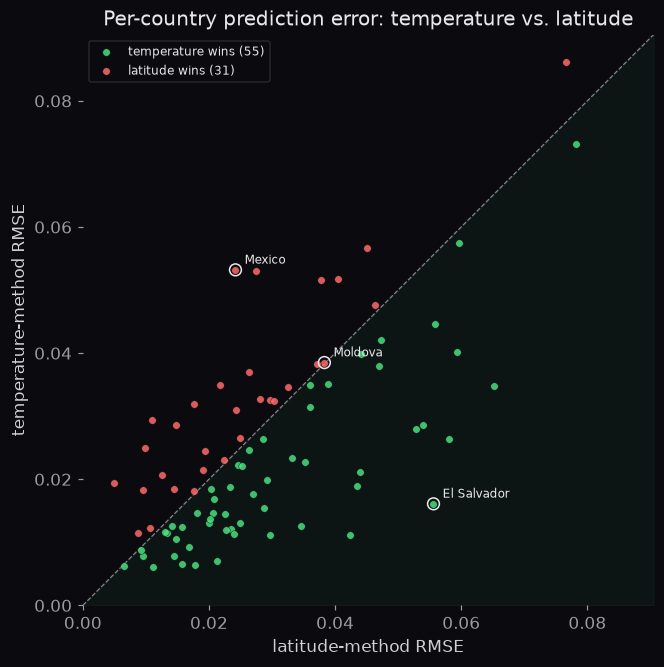

Each point is one held-out country (n=86). Below the dashed diagonal means
temperature reconstructed that country's curve more accurately than latitude alone —
55 of 86 countries (64%) land there.


In [5]:
# Per-Country Win/Loss — latitude RMSE vs. temperature RMSE, one point per held-out country.
per_country = loo["perCountry"]
lat_rmse_vals = np.array([c["latitude_rmse"] for c in per_country])
temp_rmse_vals = np.array([c["temperature_rmse"] for c in per_country])
win = temp_rmse_vals < lat_rmse_vals

fig, ax = plt.subplots(figsize=(6.2, 6.2))
lo, hi = 0, max(lat_rmse_vals.max(), temp_rmse_vals.max()) * 1.05
ax.plot([lo, hi], [lo, hi], color="#888", linewidth=0.8, linestyle="--", zorder=1)
ax.fill_between([lo, hi], [lo, hi], lo, color="#4ade80", alpha=0.05, zorder=0)

ax.scatter(lat_rmse_vals[win], temp_rmse_vals[win], s=24, color="#4ade80", alpha=0.85,
           edgecolors="#0a0a0f", linewidths=0.3, zorder=3, label=f"temperature wins ({int(win.sum())})")
ax.scatter(lat_rmse_vals[~win], temp_rmse_vals[~win], s=24, color="#ff6b6b", alpha=0.85,
           edgecolors="#0a0a0f", linewidths=0.3, zorder=3, label=f"latitude wins ({int((~win).sum())})")

for ex in loo["examples"]:
    idx = next(i for i, c in enumerate(per_country) if c["m49"] == ex["m49"])
    ax.annotate(ex["name"], (lat_rmse_vals[idx], temp_rmse_vals[idx]), fontsize=8, color="#e8e8ea",
                xytext=(6, 4), textcoords="offset points", zorder=4)
    ax.scatter([lat_rmse_vals[idx]], [temp_rmse_vals[idx]], s=60, facecolors="none",
               edgecolors="#e8e8ea", linewidths=1.0, zorder=4)

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal")
ax.set_xlabel("latitude-method RMSE")
ax.set_ylabel("temperature-method RMSE")
ax.set_title("Per-country prediction error: temperature vs. latitude", fontsize=13, color="#e8e8ea")
ax.legend(fontsize=8, framealpha=0.15, loc="upper left")
for s in ax.spines.values():
    s.set_visible(False)
plt.tight_layout()
plt.show()
print(f"Each point is one held-out country (n={len(per_country)}). Below the dashed diagonal means\n"
      f"temperature reconstructed that country's curve more accurately than latitude alone —\n"
      f"{int(win.sum())} of {len(per_country)} countries ({100 * win.mean():.0f}%) land there.")


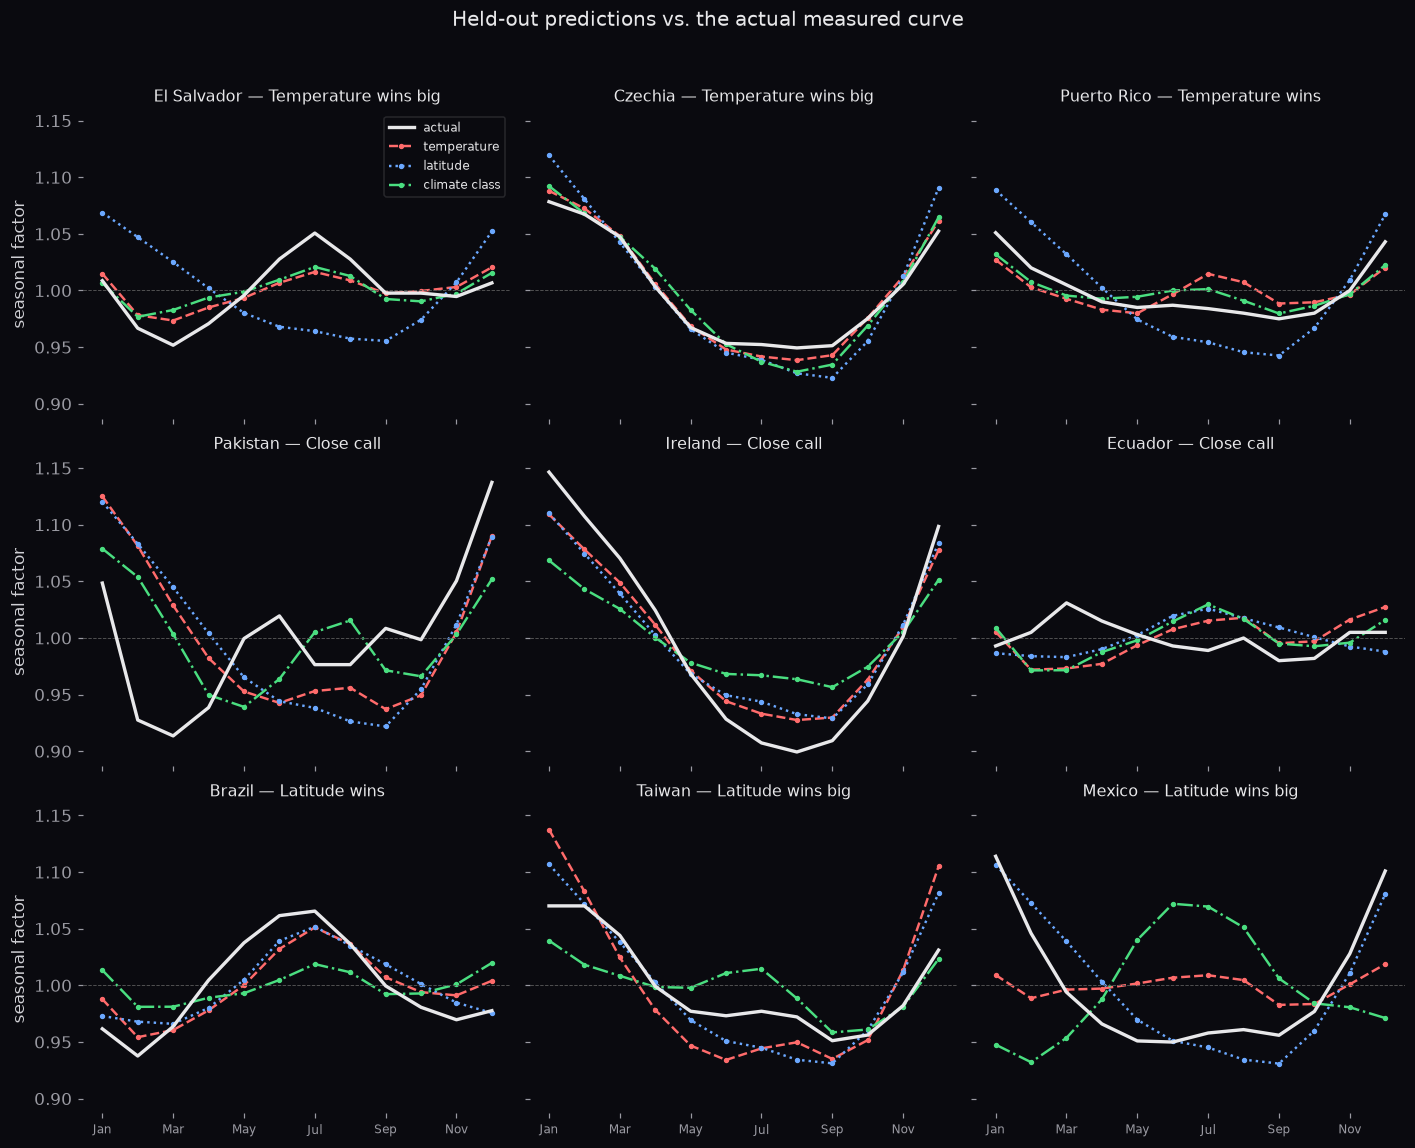

El Salvador    (Temperature wins big  ) — latitude RMSE 0.056, temperature RMSE 0.016, climate RMSE 0.017
Czechia        (Temperature wins big  ) — latitude RMSE 0.021, temperature RMSE 0.007, climate RMSE 0.012
Puerto Rico    (Temperature wins      ) — latitude RMSE 0.027, temperature RMSE 0.018, climate RMSE 0.012
Pakistan       (Close call            ) — latitude RMSE 0.078, temperature RMSE 0.073, climate RMSE 0.061
Ireland        (Close call            ) — latitude RMSE 0.025, temperature RMSE 0.022, climate RMSE 0.048
Ecuador        (Close call            ) — latitude RMSE 0.025, temperature RMSE 0.026, climate RMSE 0.027
Brazil         (Latitude wins         ) — latitude RMSE 0.019, temperature RMSE 0.021, climate RMSE 0.037
Taiwan         (Latitude wins big     ) — latitude RMSE 0.026, temperature RMSE 0.037, climate RMSE 0.026
Mexico         (Latitude wins big     ) — latitude RMSE 0.024, temperature RMSE 0.053, climate RMSE 0.095


In [17]:
# Held-Out Predictions — actual vs. predicted curve across 9 examples spread evenly across
# the win/loss distribution, from "temperature wins big" to "latitude wins big".
examples = loo["examples"]
ncols = 3
nrows = math.ceil(len(examples) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.4 * nrows), sharey=True, sharex=True)
axes_flat = axes.flatten()
x = range(1, 13)
for ax, ex in zip(axes_flat, examples, strict=True):
    ax.plot(x, ex["actual"], color="#e8e8ea", linewidth=2.2, label="actual", zorder=3)
    ax.plot(x, ex["temperature_prediction"], color="#ff6b6b", linewidth=1.6,
            linestyle="--", marker="o", markersize=2.5, label="temperature")
    ax.plot(x, ex["latitude_prediction"], color="#6ba8ff", linewidth=1.6,
            linestyle=":", marker="o", markersize=2.5, label="latitude")
    ax.plot(x, ex["climate_prediction"], color="#4ade80", linewidth=1.6,
            linestyle="-.", marker="o", markersize=2.5, label="climate class")
    ax.axhline(1, color="#555", linewidth=0.6, linestyle="--")
    ax.set_xticks(list(x)[::2])
    ax.set_xticklabels([MONTHS[i] for i in range(0, 12, 2)], fontsize=8)
    ax.set_title(f"{ex['name']} — {ex['label']}", fontsize=10.5, color="#e8e8ea")
    for s in ax.spines.values():
        s.set_visible(False)
for ax in axes_flat[len(examples):]:
    ax.set_visible(False)
for row in axes if nrows > 1 else [axes]:
    row[0].set_ylabel("seasonal factor")
axes_flat[0].legend(fontsize=8, framealpha=0.15, loc="upper right")
fig.suptitle("Held-out predictions vs. the actual measured curve", fontsize=13, color="#e8e8ea", y=1.02)
plt.tight_layout()
plt.show()
for ex in examples:
    print(f"{ex['name']:14s} ({ex['label']:22s}) — latitude RMSE {ex['latitude_rmse']:.3f}, "
          f"temperature RMSE {ex['temperature_rmse']:.3f}, climate RMSE {ex['climate_rmse']:.3f}")


**Does the error pattern track climate zone?** — Grouping the 86 countries into the same four
climate-zone bands used by the Latitude Correlation chart above (by centroid `|latitude|`),
temperature's advantage turns out to concentrate in the tropics rather than spreading evenly:
the latitude fallback forces every country's *shape* toward a canonical northern-winter-peaked
curve, which fits countries with genuine winter/summer seasons but breaks for tropical countries
whose real mortality timing follows a wet/dry season cycle with no "winter" at all.

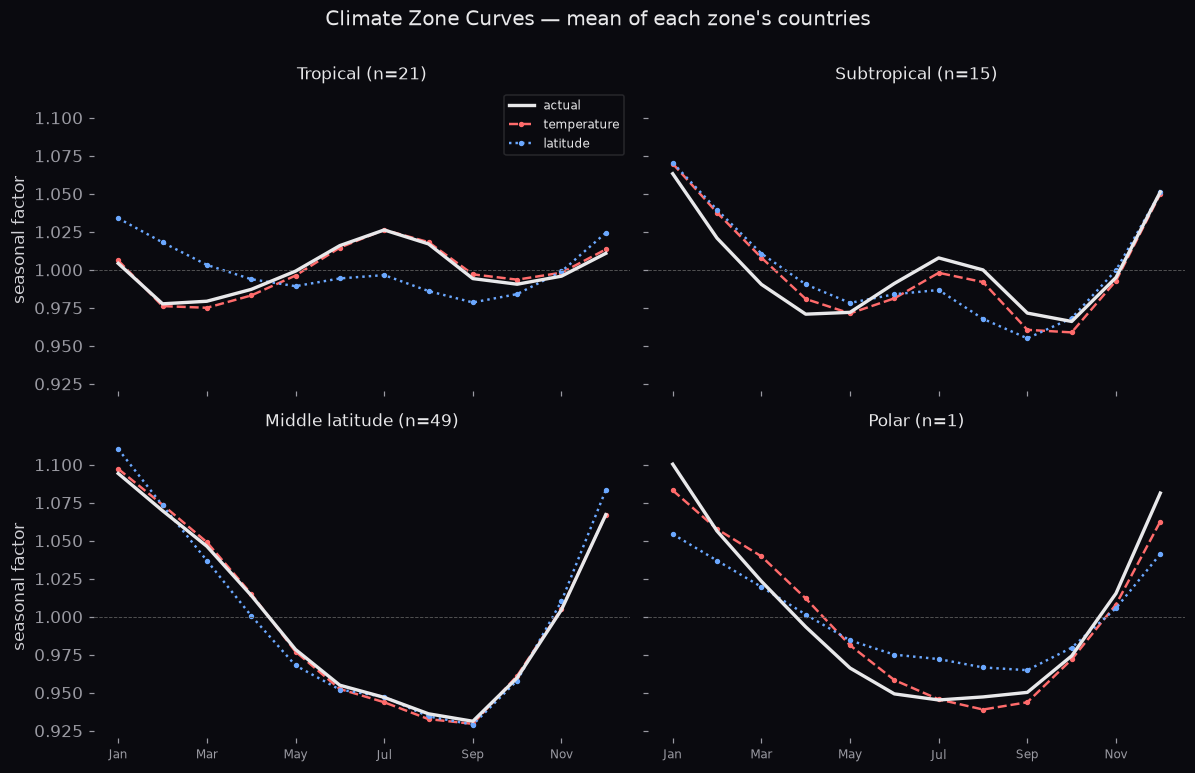

Each panel averages the (renormalized) actual and predicted curves across every country in
that zone. The Polar zone holds a single country, so its curve is one country's, not a
stable average -- shown for completeness, not as a pattern.


In [14]:
# Climate Zone Curves — mean actual vs. predicted curve, averaged within each climate zone.
zones = loo["climateZones"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharey=True, sharex=True)
axes_flat = axes.flatten()
x = range(1, 13)
for ax, z in zip(axes_flat, zones, strict=True):
    ax.plot(x, z["actual"], color="#e8e8ea", linewidth=2.2, label="actual", zorder=3)
    ax.plot(x, z["temperature_prediction"], color="#ff6b6b", linewidth=1.6,
            linestyle="--", marker="o", markersize=2.5, label="temperature")
    ax.plot(x, z["latitude_prediction"], color="#6ba8ff", linewidth=1.6,
            linestyle=":", marker="o", markersize=2.5, label="latitude")
    ax.axhline(1, color="#555", linewidth=0.6, linestyle="--")
    ax.set_xticks(list(x)[::2])
    ax.set_xticklabels([MONTHS[i] for i in range(0, 12, 2)], fontsize=8)
    ax.set_title(f"{z['zone']} (n={z['n']})", fontsize=11, color="#e8e8ea")
    for s in ax.spines.values():
        s.set_visible(False)
for ax in axes_flat[len(zones):]:
    ax.set_visible(False)
for row in axes:
    row[0].set_ylabel("seasonal factor")
axes_flat[0].legend(fontsize=8, framealpha=0.15, loc="upper right")
fig.suptitle("Climate Zone Curves — mean of each zone's countries", fontsize=13, color="#e8e8ea", y=1.0)
plt.tight_layout()
plt.show()
print("Each panel averages the (renormalized) actual and predicted curves across every country in\n"
      "that zone. The Polar zone holds a single country, so its curve is one country's, not a\n"
      "stable average -- shown for completeness, not as a pattern.")


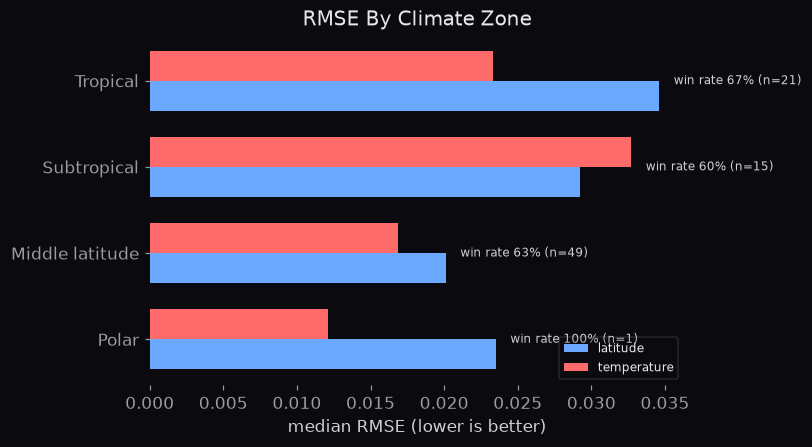

Temperature's win rate and margin are both largest in the tropics; in the subtropics the
two methods are close enough that temperature's median RMSE is actually slightly worse even
though it still wins more countries than it loses.


In [15]:
# RMSE By Climate Zone — median RMSE, latitude vs. temperature, grouped by zone.
zone_names = [z["zone"] for z in zones]
lat_zone_rmse = [z["latitude_median_rmse"] for z in zones]
temp_zone_rmse = [z["temperature_median_rmse"] for z in zones]
win_rates = [z["temperature_win_rate"] for z in zones]

y = np.arange(len(zones))
h = 0.35
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.barh(y + h / 2, lat_zone_rmse, height=h, color="#6ba8ff", label="latitude")
ax.barh(y - h / 2, temp_zone_rmse, height=h, color="#ff6b6b", label="temperature")
for yi, (lv, tv, wr, n) in enumerate(zip(lat_zone_rmse, temp_zone_rmse, win_rates, [z["n"] for z in zones], strict=True)):
    ax.text(max(lv, tv) + 0.001, yi, f"win rate {wr:.0%} (n={n})", va="center", fontsize=8, color="#cfcfd4")
ax.set_yticks(y)
ax.set_yticklabels([f"{name}" for name in zone_names])
ax.invert_yaxis()
ax.set_xlabel("median RMSE (lower is better)")
ax.set_title("RMSE By Climate Zone", fontsize=13, color="#e8e8ea")
ax.legend(fontsize=8, framealpha=0.15, loc="lower right")
for s in ax.spines.values():
    s.set_visible(False)
plt.tight_layout()
plt.show()
print("Temperature's win rate and margin are both largest in the tropics; in the subtropics the\n"
      "two methods are close enough that temperature's median RMSE is actually slightly worse even\n"
      "though it still wins more countries than it loses.")


### ● 5 · Death Rate By Region

There are mortality differences between regions inside a single country, beyond the national average.

> Source: IHME Global Burden of Disease 2023 (all-cause crude death rate) worldwide, and Eurostat 2023 NUTS-2 rates across Europe, joined to Natural Earth and GISCO regions.

A single national rate hides enormous internal spread. In Japan, rural **Akita** dies at
nearly twice the rate of **Tokyo**; in the US, **West Virginia** runs well above
**Utah**; in Europe, north-west **Bulgaria** and eastern Germany far exceed **Ireland**
or the Nordic capitals. Most of the gap is age structure — older regions bury more of
their people each year — layered over real differences in health, poverty, and access to care.

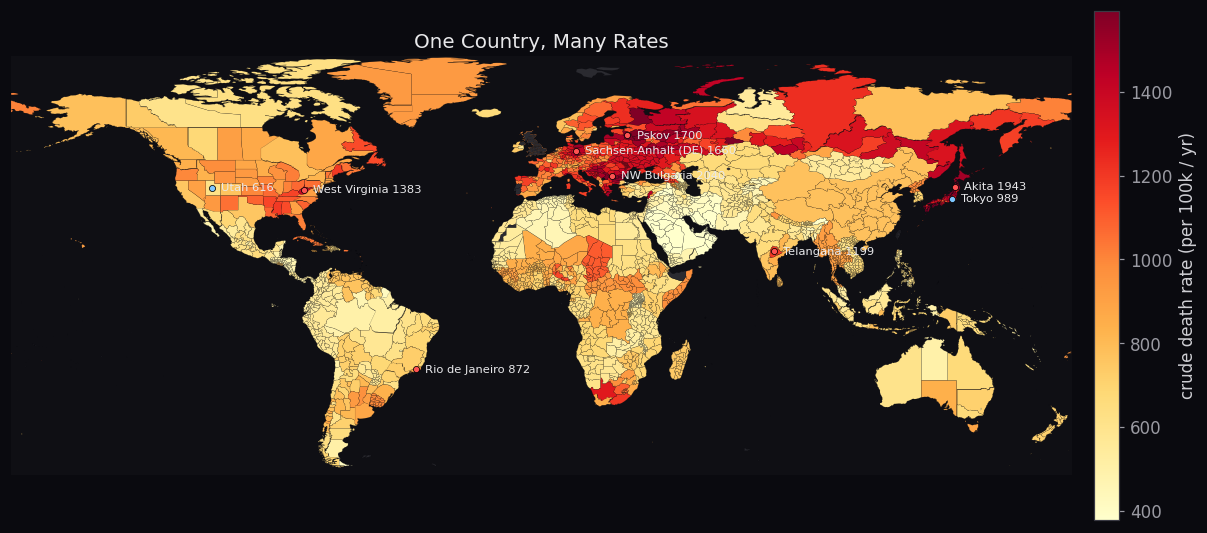

Every first-level region colored by its own crude death rate. Inside a single country
the spread is dramatic — Russia's is the widest of all, Pskov running over 5× Ingushetia;
rural Akita nearly 2× Tokyo, West Virginia well above Utah, north-west Bulgaria far above
Ireland. Countries without regional data (China, most of Africa) are shaded a flat
national rate instead.

Subnational data covers 981 regions across 72 countries; every other country keeps its single national rate.

Sources: IHME Global Burden of Disease 2023 (crude, all-cause) worldwide; Eurostat 2023
NUTS-2 for Europe; national statistical offices for Russia, Canada, Australia (2023),
Argentina and Chile (2022) — Rosstat, StatCan, ABS, DEIS. Most of the gap reflects age
structure, then real health differences.


In [11]:
# One Country, Many Rates — subnational choropleth (NUTS-2 in Europe, Admin-1 elsewhere).
rate_by_key = {r["key"]: r["ratePer100k"] for r in subnational["regions"]}
rate_by_country = dict(subnational["countryRates"])          # ISO3 -> national rate
nuts_countries = set(subnational["meta"]["nutsCountriesIso3"])

adm1 = decode_topojson(admin1, "ne_10m_admin_1")
nut = decode_topojson(nuts2, "nuts2_20m")

# Merge into one draw list: drop Natural Earth regions in NUTS-covered countries.
drawn = []
for f in adm1:
    if f["props"].get("adm0_a3") not in nuts_countries:
        drawn.append({"rings": f["rings"], "key": f["props"].get("adm1_code"),
                      "name": f["props"].get("name"), "country": f["props"].get("adm0_a3")})
for f in nut:
    drawn.append({"rings": f["rings"], "key": f["props"].get("NUTS_ID"),
                  "name": f["props"].get("NAME_LATN"), "country": None})

# Sequential scale over all drawn rates (regional + national fallback), clamped 2nd-98th pct.
all_rates = np.array(sorted([*rate_by_key.values(), *rate_by_country.values()]))
lo, hi = np.quantile(all_rates, 0.02), np.quantile(all_rates, 0.98)
norm = Normalize(lo, hi)
cmap = plt.get_cmap("YlOrRd")
NO_DATA = "#2a2a30"


def rate_of(d):
    own = rate_by_key.get(d["key"])
    if own is not None:
        return own, False
    nat = rate_by_country.get(d["country"]) if d["country"] else None
    return (nat, True) if nat is not None else (None, False)


fig, ax = plt.subplots(figsize=(13, 6.5))
ax.add_collection(PolyCollection([[(-180, -90), (180, -90), (180, 90), (-180, 90)]],
                                 facecolor="#ffffff06", edgecolor="none"))
for d in drawn:
    rate, _nat = rate_of(d)
    color = cmap(norm(rate)) if rate is not None else NO_DATA
    if d["rings"]:
        ax.add_collection(PolyCollection(d["rings"], facecolor=color,
                                         edgecolor="#0a0a0f", linewidth=0.08))

# Callout leader dots + labels (matched by globally-unique region name).
CALLOUTS = [("Akita", "high", None), ("Tokyo", "low", None),
            ("West Virginia", "high", None), ("Utah", "low", None),
            ("Telangana", "high", None), ("Rio de Janeiro", "high", None),
            ("Severozapaden", "high", "NW Bulgaria"),
            ("Sachsen-Anhalt", "high", "Sachsen-Anhalt (DE)"), ("Pskov", "high", None)]
by_name = {d["name"]: d for d in drawn}
for name, kind, label in CALLOUTS:
    d = by_name.get(name)
    if not d:
        continue
    c = polygon_centroid(d["rings"])
    rate = rate_by_key.get(d["key"])
    if c and rate is not None:
        ax.plot(c[0], c[1], "o", markersize=4,
                color="#ff5252" if kind == "high" else "#7ec8ff",
                markeredgecolor="black", markeredgewidth=0.5, zorder=5)
        ax.annotate(f"{label or name} {round(rate)}", (c[0], c[1]),
                    xytext=(6, 0), textcoords="offset points", fontsize=7.5,
                    color="#e8e8ea", zorder=5, va="center")

style_world(ax, "One Country, Many Rates")
ax.set_ylim(-58, 84)
cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, fraction=0.023, pad=0.02)
cbar.set_label("crude death rate (per 100k / yr)", color="#cfcfd4")
plt.show()
print("Every first-level region colored by its own crude death rate. Inside a single country\n"
      "the spread is dramatic — Russia's is the widest of all, Pskov running over 5× Ingushetia;\n"
      "rural Akita nearly 2× Tokyo, West Virginia well above Utah, north-west Bulgaria far above\n"
      "Ireland. Countries without regional data (China, most of Africa) are shaded a flat\n"
      "national rate instead.\n")
print(f"Subnational data covers {subnational['meta']['regionCount']} regions across "
      f"{subnational['meta']['countryCount']} countries; every other country keeps its single "
      "national rate.\n")
print("Sources: IHME Global Burden of Disease 2023 (crude, all-cause) worldwide; Eurostat 2023\n"
      "NUTS-2 for Europe; national statistical offices for Russia, Canada, Australia (2023),\n"
      "Argentina and Chile (2022) — Rosstat, StatCan, ABS, DEIS. Most of the gap reflects age\n"
      "structure, then real health differences.")


### ○ 6 · Ongoing Conflicts

Conflicts increase mortality in specific regions by a measurable amount.

> Source: TBD

### ○ 7 · Ongoing Epidemics

Epidemics raise mortality in specific regions and periods by a measurable amount.

> Source: TBD

### ○ 8 · Death Rate By Time Of Day

Timing shifts by hour for causes with circadian patterns, such as cardiovascular events and injuries.

> Source: TBD

---

The globe is statistical, not a feed of individual records. A flash and persona should be
read as a representative event drawn from public aggregate data, never as an identifiable
death.

*This is a personal project exploring statistical mortality visualization.*